# MODMA 3-Channel EEG Depression Detection
## Ultra Memory-Safe VMD + LightGBM Pipeline for Kaggle

This version is specifically designed for the Kaggle **RAM restart** that can occur during long VMD feature extraction.

### Critical engineering change
Each subject is processed inside a **fresh child process**. The child loads one EEG recording, filters it, extracts a small number of VMD-window features, saves them to disk, and then exits. When the process exits, the operating system releases all memory used by `vmdpy`, NumPy, SciPy, and entropy calculations—even memory that ordinary `del` and `gc.collect()` may not return to the OS.

### Safe preset
- 4-second non-overlapping windows
- **12 windows/subject = 48 seconds of EEG per subject**
- VMD with **K = 4**
- First **3 IMFs** retained
- Sample Entropy + RMS + PSD energy
- Per-subject disk cache
- Leakage-safe **subject-level 5-fold cross-validation**
- Final **subject-level** metrics and report-ready visualizations

> First complete the notebook with the safe preset. If stable, increase `MAX_WINDOWS_PER_SUBJECT` to 18 and then 24 as a sensitivity analysis. Do not jump directly to full-record VMD.

> `FS = 250 Hz` and channel labels are retained from the working notebook. Verify them against MODMA documentation before final publication.

## 1. Install and Import

In [52]:
%pip -q install vmdpy antropy lightgbm

Note: you may need to restart the kernel to use updated packages.


In [54]:
import os
import gc
import time
import warnings
import multiprocessing as mp
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal
from vmdpy import VMD
import antropy as ant

import lightgbm as lgb
from lightgbm import LGBMClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

print("LightGBM:", lgb.__version__)
print("CPU cores:", os.cpu_count())

LightGBM: 4.6.0
CPU cores: 4


## 2. Configuration — Safe Kaggle Preset

In [55]:
# -------------------- Dataset --------------------
EXPECTED_ROOT = Path("/kaggle/input/datasets/manavrajpurohit/modma-dataset")
METADATA_NAME = "3channel_modma_dataset.csv"

# -------------------- EEG ------------------------
FS = 250                     # Verify from MODMA documentation
CHANNEL_NAMES = ["Fp1", "Fpz", "Fp2"]
LOWCUT = 1.0
HIGHCUT = 45.0

# 4-second non-overlapping windows
WINDOW_SEC = 4.0
WINDOW_SAMPLES = int(FS * WINDOW_SEC)

# ULTRA-SAFE PRESET: 12 × 4 s = 48 s per subject
MAX_WINDOWS_PER_SUBJECT = 12

# -------------------- VMD ------------------------
# Lighter than the earlier configuration.
VMD_K = 4
N_SELECTED_IMFS = 3
VMD_ALPHA = 2000
VMD_TAU = 0.0
VMD_DC = 0
VMD_INIT = 1
VMD_TOL = 1e-5

# -------------------- Labels ---------------------
LABEL_MAP = {"HC": 0, "MDD": 1}

# -------------------- CV / Model -----------------
N_SPLITS = 5

# Use a NEW cache name so old 30-window / K=5 caches are never mixed in.
CACHE_DIR = Path("/kaggle/working/modma_vmd_ultrasafe_w12_k4_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("Window length:", WINDOW_SEC, "s")
print("Max windows/subject:", MAX_WINDOWS_PER_SUBJECT)
print("EEG used/subject:", MAX_WINDOWS_PER_SUBJECT * WINDOW_SEC, "s")
print("VMD K:", VMD_K, "| retained IMFs:", N_SELECTED_IMFS)
print("Cache:", CACHE_DIR)

Window length: 4.0 s
Max windows/subject: 12
EEG used/subject: 48.0 s
VMD K: 4 | retained IMFs: 3
Cache: /kaggle/working/modma_vmd_ultrasafe_w12_k4_cache


## 3. Locate Dataset and Load Metadata

Only the diagnosis label is used as the target. Questionnaire variables such as PHQ-9 are **not** used as EEG model inputs.

In [56]:
def locate_metadata():
    direct = EXPECTED_ROOT / METADATA_NAME
    if direct.exists():
        return direct

    matches = list(Path("/kaggle/input").rglob(METADATA_NAME))
    if not matches:
        raise FileNotFoundError(f"{METADATA_NAME} not found under /kaggle/input")
    return matches[0]

METADATA_FILE = locate_metadata()
DATASET_ROOT = METADATA_FILE.parent

metadata = pd.read_csv(METADATA_FILE)

txt_files = list(DATASET_ROOT.rglob("*.txt"))

def subject_code(subject_id):
    return f"{int(subject_id):08d}"

def match_file(subject_id):
    code = subject_code(subject_id)
    matches = [str(p) for p in txt_files if code in p.name]
    return matches[0] if matches else None

metadata["eeg_file"] = metadata["subject id"].apply(match_file)
metadata["label"] = metadata["type"].map(LABEL_MAP)

data_df = metadata.dropna(subset=["eeg_file", "label"]).copy()
data_df["label"] = data_df["label"].astype(int)

print("Dataset root:", DATASET_ROOT)
print("Subjects:", len(data_df))
print("Matched EEG files:", data_df["eeg_file"].notna().sum())
print("\nClass counts:")
print(data_df["type"].value_counts())

Dataset root: /kaggle/input/datasets/manavrajpurohit/modma-dataset
Subjects: 55
Matched EEG files: 55

Class counts:
type
HC     29
MDD    26
Name: count, dtype: int64


## 4. Dataset Visualization

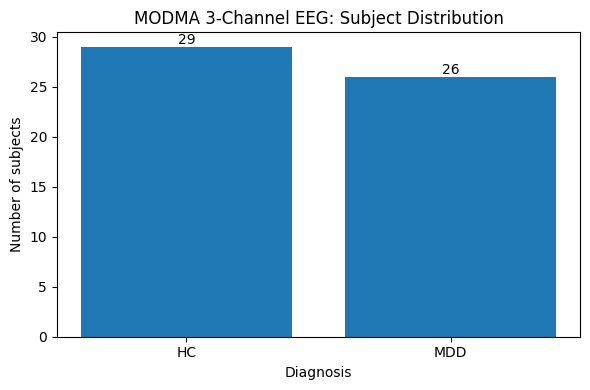

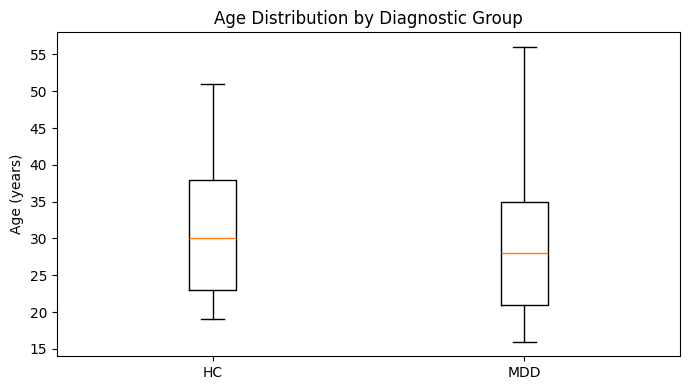

In [57]:
# Figure 1: class distribution
counts = data_df["type"].value_counts().reindex(["HC", "MDD"])

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values)

for b in bars:
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + 0.3,
        f"{int(b.get_height())}",
        ha="center"
    )

ax.set_title("MODMA 3-Channel EEG: Subject Distribution")
ax.set_ylabel("Number of subjects")
ax.set_xlabel("Diagnosis")
plt.tight_layout()
plt.show()

# Figure 2: age distribution by diagnosis (descriptive/confounding check)
if "age" in data_df.columns:
    fig, ax = plt.subplots(figsize=(7, 4))
    age_hc = data_df.loc[data_df["type"] == "HC", "age"].dropna()
    age_mdd = data_df.loc[data_df["type"] == "MDD", "age"].dropna()
    ax.boxplot([age_hc, age_mdd], tick_labels=["HC", "MDD"])
    ax.set_title("Age Distribution by Diagnostic Group")
    ax.set_ylabel("Age (years)")
    plt.tight_layout()
    plt.show()

## 5. EEG Loading and Preprocessing

Pipeline:

\[
x(t)
ightarrow 	ext{finite-value repair}

ightarrow 	ext{detrending}

ightarrow 1	ext{--}45\,\mathrm{Hz}\ 	ext{band-pass}
\]

A 4th-order Butterworth SOS filter is used because it is considerably lighter than the previous 501-tap FIR implementation.

In [58]:
def load_eeg(file_path, expected_channels=3):
    eeg = np.loadtxt(file_path, dtype=np.float32)

    if eeg.ndim != 2:
        raise ValueError(f"Expected 2-D EEG, got {eeg.shape}")

    if eeg.shape[1] == expected_channels:
        pass
    elif eeg.shape[0] == expected_channels:
        eeg = eeg.T
    else:
        raise ValueError(f"Cannot identify 3 channels; shape={eeg.shape}")

    return np.ascontiguousarray(eeg, dtype=np.float32)


SOS = signal.butter(
    4,
    [LOWCUT, HIGHCUT],
    btype="bandpass",
    fs=FS,
    output="sos"
)


def preprocess_eeg(eeg):
    x = np.asarray(eeg, dtype=np.float32).copy()

    # Repair non-finite samples by linear interpolation.
    for ch in range(x.shape[1]):
        good = np.isfinite(x[:, ch])
        if not good.all():
            if good.sum() < 2:
                raise ValueError("Insufficient finite samples")
            idx = np.arange(len(x))
            x[~good, ch] = np.interp(idx[~good], idx[good], x[good, ch])

    # Remove linear trend.
    x = signal.detrend(x, axis=0, type="linear")

    # Efficient zero-phase IIR filtering.
    x = signal.sosfiltfilt(SOS, x, axis=0)

    return np.asarray(x, dtype=np.float32)

Subject: 2010002 MDD
Raw shape: (298260, 3)
Duration: 19.88 min


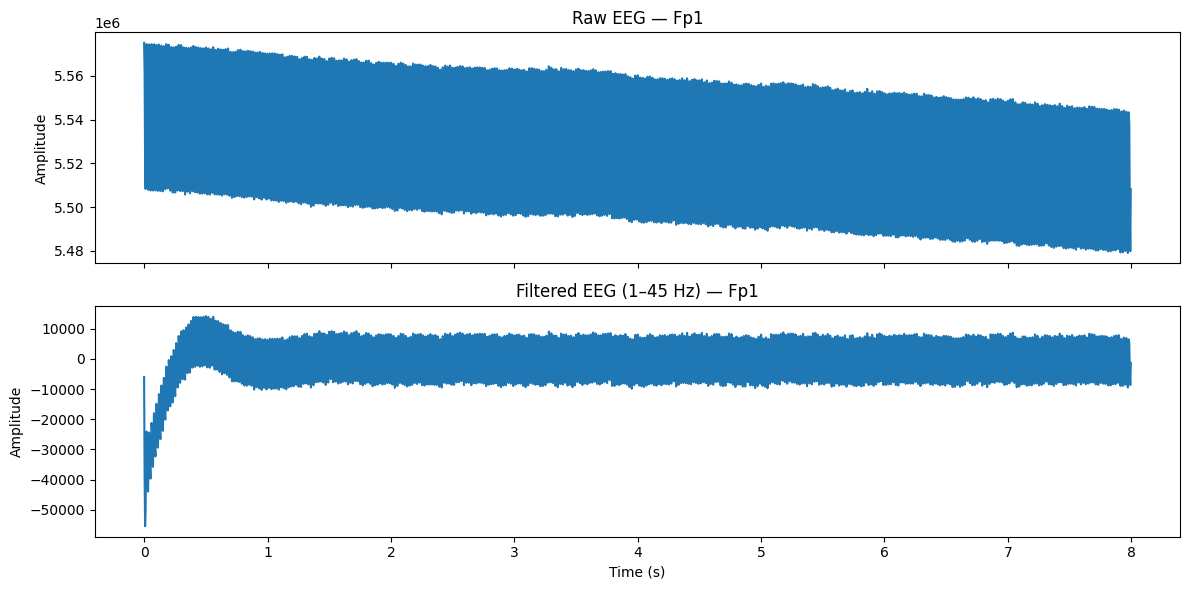

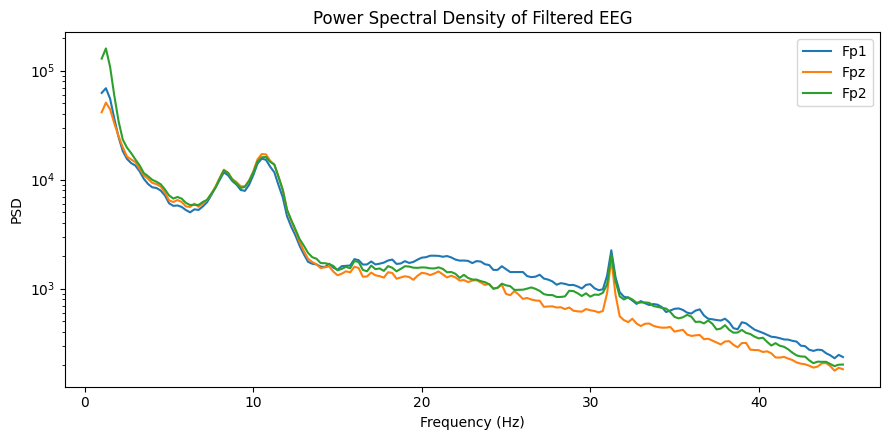

25528

In [59]:
# Inspect one subject
sample_row = data_df.iloc[0]
sample_raw = load_eeg(sample_row["eeg_file"])
sample_filtered = preprocess_eeg(sample_raw)

print("Subject:", int(sample_row["subject id"]), sample_row["type"])
print("Raw shape:", sample_raw.shape)
print("Duration:", round(len(sample_raw) / FS / 60, 2), "min")

# Report Figure 3: raw vs filtered
seconds = 8
n = min(int(seconds * FS), len(sample_raw))
t = np.arange(n) / FS

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t, sample_raw[:n, 0])
axes[0].set_title(f"Raw EEG — {CHANNEL_NAMES[0]}")
axes[0].set_ylabel("Amplitude")

axes[1].plot(t, sample_filtered[:n, 0])
axes[1].set_title(f"Filtered EEG (1–45 Hz) — {CHANNEL_NAMES[0]}")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

# Report Figure 4: PSD after filtering
fig, ax = plt.subplots(figsize=(9, 4.5))
for ch, name in enumerate(CHANNEL_NAMES):
    f, pxx = signal.welch(
        sample_filtered[:, ch],
        fs=FS,
        nperseg=min(4 * FS, len(sample_filtered))
    )
    mask = (f >= 1) & (f <= 45)
    ax.semilogy(f[mask], pxx[mask], label=name)

ax.set_title("Power Spectral Density of Filtered EEG")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD")
ax.legend()
plt.tight_layout()
plt.show()

del sample_raw, sample_filtered
gc.collect()

## 6. Equal-Length Central Window Selection

To reduce RAM/runtime and avoid allowing long recordings to dominate the model, each subject contributes at most the same number of windows.

For the safe preset:

\[
30\ 	ext{windows}	imes4\ 	ext{s}=120\ 	ext{s/subject}
\]

The windows are taken from the **central portion** of the recording.

In [60]:
def central_windows(eeg):
    n_available = len(eeg) // WINDOW_SAMPLES
    n_use = min(MAX_WINDOWS_PER_SUBJECT, n_available)

    total_use = n_use * WINDOW_SAMPLES
    start = max(0, (len(eeg) - total_use) // 2)
    segment = eeg[start:start + total_use]

    # View, not a large copied window tensor.
    for i in range(n_use):
        a = i * WINDOW_SAMPLES
        b = a + WINDOW_SAMPLES
        yield i, segment[a:b]

## 7. Window-Level VMD Feature Extraction — RAM-Safe

**Critical change:** VMD is executed on a 4-second window, not on the entire 20-minute channel.

For every retained IMF:

- Sample Entropy
- RMS
- PSD energy (1–45 Hz)

The modes are discarded immediately after the features are calculated.

In [63]:
def safe_sampen(x):
    x = np.asarray(x, dtype=np.float64)
    sd = np.std(x)

    if len(x) < 10 or not np.isfinite(x).all():
        return np.nan
    if sd < 1e-12:
        return 0.0

    z = (x - np.mean(x)) / sd

    try:
        value = ant.sample_entropy(z, order=2, metric="chebyshev")
        return float(value) if np.isfinite(value) else np.nan
    except Exception:
        return np.nan


def rms(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.sqrt(np.mean(x * x)))


def psd_energy(x):
    x = np.asarray(x, dtype=np.float64)
    f, pxx = signal.welch(x, fs=FS, nperseg=min(FS, len(x)))
    mask = (f >= LOWCUT) & (f <= HIGHCUT)
    if mask.sum() < 2:
        return 0.0
    return float(np.trapezoid(pxx[mask], f[mask]))


def vmd_features_for_window(window):
    out = {}

    for ch_idx, ch_name in enumerate(CHANNEL_NAMES):
        x = np.asarray(window[:, ch_idx], dtype=np.float64)
        x = x - np.mean(x)
        sd = np.std(x)
        if sd > 1e-12:
            x = x / sd

        modes, _, _ = VMD(
            x,
            VMD_ALPHA,
            VMD_TAU,
            VMD_K,
            VMD_DC,
            VMD_INIT,
            VMD_TOL
        )

        # Extract and immediately discard.
        for imf_idx in range(N_SELECTED_IMFS):
            imf = modes[imf_idx]
            prefix = f"{ch_name}_IMF{imf_idx+1}"

            out[f"{prefix}_SampEn"] = safe_sampen(imf)
            out[f"{prefix}_RMS"] = rms(imf)
            out[f"{prefix}_PSD"] = psd_energy(imf)

        del modes

    return out

## 8. RAM-Isolated Feature Extraction with Per-Subject Checkpoints

This is the key change that prevents cumulative RAM growth.

For each participant:

```text
fresh child process
      ↓
load one EEG
      ↓
preprocess
      ↓
12 central windows
      ↓
window-wise VMD + features
      ↓
save one small CSV
      ↓
child process exits
      ↓
OS reclaims all child RAM
```

The parent Kaggle kernel never keeps raw EEG or VMD arrays for multiple participants. Existing cache files are reused after a restart.

In [64]:
def extract_subject_to_disk(row_dict):
    """Run inside a fresh child process and save one subject's features."""
    subject_id = int(row_dict["subject id"])
    cache_file = CACHE_DIR / f"{subject_id:08d}.csv"

    # Resume support
    if cache_file.exists():
        return

    eeg = load_eeg(row_dict["eeg_file"])
    eeg = preprocess_eeg(eeg)

    feature_rows = []

    for window_idx, window in central_windows(eeg):
        features = vmd_features_for_window(window)

        features.update({
            "subject_id": subject_id,
            "diagnosis": row_dict["type"],
            "label": int(row_dict["label"]),
            "window_idx": int(window_idx)
        })

        feature_rows.append(features)

        # Important: do not preserve window/VMD objects.
        del features

    subject_features = pd.DataFrame(feature_rows)

    feature_cols = [
        c for c in subject_features.columns
        if c not in {"subject_id", "diagnosis", "label", "window_idx"}
    ]

    subject_features[feature_cols] = subject_features[feature_cols].astype(np.float32)
    subject_features.to_csv(cache_file, index=False)

    # No return of DataFrame. The process exits here and the OS reclaims its RAM.


# Kaggle is Linux; fork lets notebook-defined functions run in child processes.
ctx = mp.get_context("fork")
rows_to_process = [row.to_dict() for _, row in data_df.iterrows()]

start_time = time.time()

for i, row_dict in enumerate(rows_to_process, start=1):
    subject_id = int(row_dict["subject id"])
    cache_file = CACHE_DIR / f"{subject_id:08d}.csv"

    if cache_file.exists():
        print(f"[{i:02d}/{len(rows_to_process)}] Subject {subject_id} cached ✅")
        continue

    print(
        f"[{i:02d}/{len(rows_to_process)}] "
        f"Subject {subject_id} | {row_dict['type']} → extracting..."
    )

    t0 = time.time()

    process = ctx.Process(
        target=extract_subject_to_disk,
        args=(row_dict,)
    )
    process.start()
    process.join()

    if process.exitcode != 0:
        raise RuntimeError(
            f"Subject {subject_id} failed in isolated process. "
            f"Exit code = {process.exitcode}."
        )

    print(f"    completed in {time.time() - t0:.1f} s ✅")

    # Parent process remains small; child RAM has already been released by the OS.
    gc.collect()

# Only now load the tiny cached tables.
cache_files = sorted(CACHE_DIR.glob("*.csv"))

print(f"\nCached subjects: {len(cache_files)}/{len(data_df)}")

if len(cache_files) == 0:
    raise RuntimeError("No subject feature cache files were created.")

frames = [pd.read_csv(f) for f in cache_files]
feature_df = pd.concat(frames, ignore_index=True)
del frames

gc.collect()

feature_df.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Feature table:", feature_df.shape)
print("Subjects:", feature_df["subject_id"].nunique())
print(
    "Feature-table RAM:",
    round(feature_df.memory_usage(deep=True).sum() / 1024**2, 2),
    "MB"
)
print("Elapsed:", round((time.time() - start_time) / 60, 2), "min")

display(feature_df.head())

[01/55] Subject 2010002 cached ✅
[02/55] Subject 2010005 cached ✅
[03/55] Subject 2010006 cached ✅
[04/55] Subject 2010007 cached ✅
[05/55] Subject 2010008 cached ✅
[06/55] Subject 2010009 cached ✅
[07/55] Subject 2010010 cached ✅
[08/55] Subject 2010011 cached ✅
[09/55] Subject 2010012 cached ✅
[10/55] Subject 2010013 cached ✅
[11/55] Subject 2010015 cached ✅
[12/55] Subject 2010016 cached ✅
[13/55] Subject 2010018 cached ✅
[14/55] Subject 2010019 cached ✅
[15/55] Subject 2010020 cached ✅
[16/55] Subject 2010021 cached ✅
[17/55] Subject 2010022 cached ✅
[18/55] Subject 2010024 cached ✅
[19/55] Subject 2010025 cached ✅
[20/55] Subject 2010026 cached ✅
[21/55] Subject 2010030 cached ✅
[22/55] Subject 2010035 cached ✅
[23/55] Subject 2030002 cached ✅
[24/55] Subject 2030003 cached ✅
[25/55] Subject 2030004 cached ✅
[26/55] Subject 2030005 cached ✅
[27/55] Subject 2030006 cached ✅
[28/55] Subject 2030007 cached ✅
[29/55] Subject 2030008 cached ✅
[30/55] Subject 2030009 cached ✅
[31/55] Su

,Fp1_IMF1_SampEn,Fp1_IMF1_RMS,Fp1_IMF1_PSD,Fp1_IMF2_SampEn,Fp1_IMF2_RMS,Fp1_IMF2_PSD,Fp1_IMF3_SampEn,Fp1_IMF3_RMS,Fp1_IMF3_PSD,Fpz_IMF1_SampEn,...,Fp2_IMF2_SampEn,Fp2_IMF2_RMS,Fp2_IMF2_PSD,Fp2_IMF3_SampEn,Fp2_IMF3_RMS,Fp2_IMF3_PSD,subject_id,diagnosis,label,window_idx
0,0.588552,0.114637,0.012272,0.114255,0.411663,0.000047,0.080853,0.637449,0.000042,0.589021,...,0.115525,0.430512,0.000036,0.099016,0.605431,0.000032,2010001,MDD,1,0
1,0.574156,0.132374,0.018700,0.118707,0.409529,0.000039,0.104004,0.692829,0.000033,0.572320,...,0.119034,0.426178,0.000032,0.102504,0.662208,0.000028,2010001,MDD,1,1
2,0.456959,0.129330,0.014868,0.118040,0.325472,0.000102,0.120041,0.676572,0.000094,0.405096,...,0.133829,0.401860,0.000067,0.117062,0.573127,0.000064,2010001,MDD,1,2
3,0.510207,0.134120,0.019161,0.092089,0.368075,0.000035,0.081505,0.610364,0.000036,0.529002,...,0.085912,0.463603,0.000026,0.080029,0.520090,0.000026,2010001,MDD,1,3
4,0.590896,0.174395,0.031689,0.084565,0.437366,0.000039,0.083226,0.536115,0.000039,0.586539,...,0.082640,0.514261,0.000029,0.083844,0.465658,0.000029,2010001,MDD,1,4


## 9. Feature Dataset Visualizations

Total features: 27
Sample entropy: 9
RMS: 9
PSD: 9


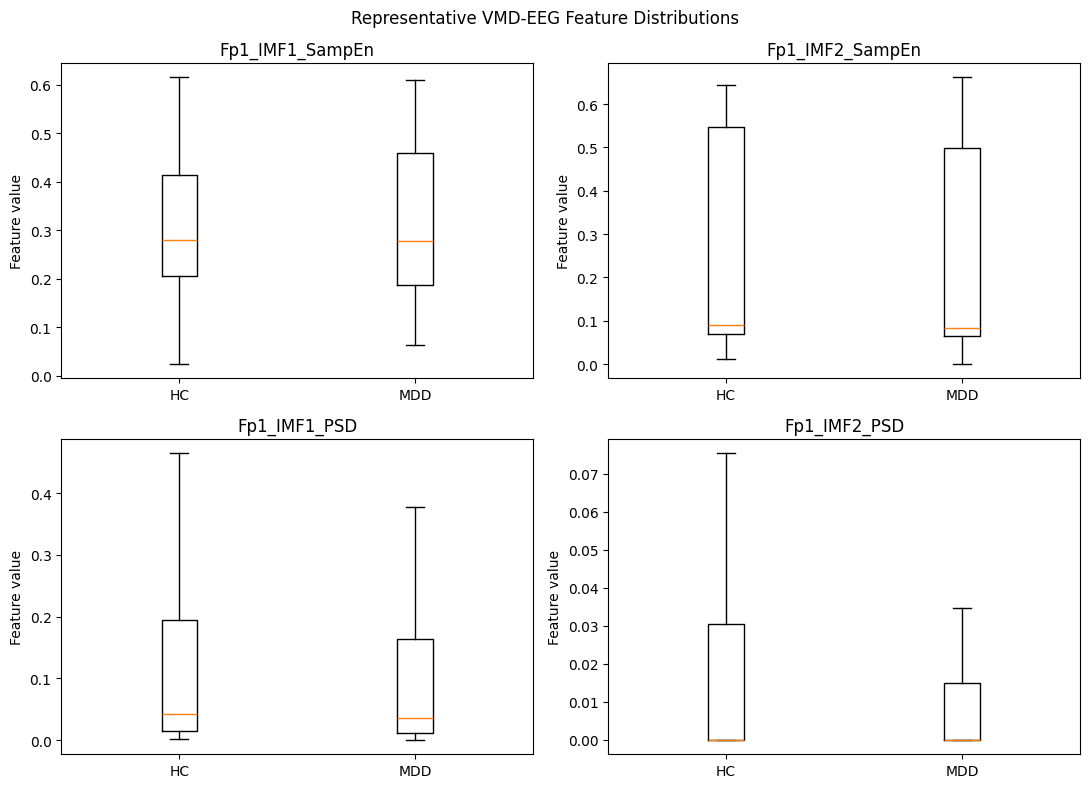

In [65]:
FEATURE_COLS = [
    c for c in feature_df.columns
    if c not in {"subject_id", "diagnosis", "label", "window_idx"}
]

SAMPEN_FEATURES = [c for c in FEATURE_COLS if c.endswith("_SampEn")]
RMS_FEATURES = [c for c in FEATURE_COLS if c.endswith("_RMS")]
PSD_FEATURES = [c for c in FEATURE_COLS if c.endswith("_PSD")]

print("Total features:", len(FEATURE_COLS))
print("Sample entropy:", len(SAMPEN_FEATURES))
print("RMS:", len(RMS_FEATURES))
print("PSD:", len(PSD_FEATURES))

# Report Figure 5: representative feature distributions.
plot_features = (SAMPEN_FEATURES[:2] + PSD_FEATURES[:2])[:4]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()

for ax, feat in zip(axes, plot_features):
    hc = feature_df.loc[feature_df["label"] == 0, feat].dropna()
    mdd = feature_df.loc[feature_df["label"] == 1, feat].dropna()

    ax.boxplot([hc, mdd], tick_labels=["HC", "MDD"], showfliers=False)
    ax.set_title(feat)
    ax.set_ylabel("Feature value")

for ax in axes[len(plot_features):]:
    ax.axis("off")

fig.suptitle("Representative VMD-EEG Feature Distributions")
plt.tight_layout()
plt.show()

# 10. Leakage-Safe Subject-Level 5-Fold Cross-Validation

The previous temporal half-split allowed **the same participant** to appear in both training and testing. That is not an independent subject-level evaluation.

Here, subjects—not windows—are divided into five folds:

\[
	ext{train subjects}\cap	ext{test subjects}=
arnothing
\]

All windows belonging to a participant stay in the same fold.

A fixed LightGBM configuration is used to keep the notebook concise and avoid expensive grid-search loops.

In [67]:
def metrics_dict(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": specificity,
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }


def detect_lgbm_device():
    # LightGBM normally uses only one GPU here; the second T4 is not required.
    try:
        probe = LGBMClassifier(
            n_estimators=2,
            num_leaves=7,
            max_bin=63,
            device_type="gpu",
            verbosity=-1
        )
        Xp = np.random.randn(100, 4).astype(np.float32)
        yp = np.array([0, 1] * 50)
        probe.fit(Xp, yp)
        print("LightGBM GPU backend available ✅")
        del probe, Xp, yp
        gc.collect()
        return "gpu"
    except Exception:
        print("LightGBM GPU backend unavailable; using CPU.")
        return "cpu"


LGBM_DEVICE = detect_lgbm_device()

MODEL_PARAMS = {
    "objective": "binary",
    "n_estimators": 250,
    "learning_rate": 0.03,
    "num_leaves": 15,
    "min_child_samples": 20,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_alpha": 0.10,
    "reg_lambda": 0.20,
    "random_state": SEED,
    "n_jobs": 2,          # avoids excessive CPU-thread RAM use
    "verbosity": -1,
    "device_type": LGBM_DEVICE,
    "max_bin": 63 if LGBM_DEVICE == "gpu" else 255
}

subject_table = (
    feature_df[["subject_id", "diagnosis", "label"]]
    .drop_duplicates("subject_id")
    .sort_values("subject_id")
    .reset_index(drop=True)
)

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

fold_rows = []
subject_predictions = []
window_predictions = []

for fold, (tr_idx, te_idx) in enumerate(
    cv.split(subject_table["subject_id"], subject_table["label"]),
    start=1
):
    train_ids = set(subject_table.iloc[tr_idx]["subject_id"])
    test_ids = set(subject_table.iloc[te_idx]["subject_id"])

    assert train_ids.isdisjoint(test_ids)

    tr = feature_df[feature_df["subject_id"].isin(train_ids)]
    te = feature_df[feature_df["subject_id"].isin(test_ids)]

    # Training-only median imputation.
    medians = tr[FEATURE_COLS].median()

    X_train = tr[FEATURE_COLS].fillna(medians).to_numpy(dtype=np.float32)
    y_train = tr["label"].to_numpy(dtype=np.int8)

    X_test = te[FEATURE_COLS].fillna(medians).to_numpy(dtype=np.float32)
    y_test = te["label"].to_numpy(dtype=np.int8)

    # Equal total contribution per subject.
    nwin = tr.groupby("subject_id")["window_idx"].transform("count").to_numpy()
    sample_weight = (1.0 / nwin).astype(np.float32)
    sample_weight *= len(sample_weight) / sample_weight.sum()

    model = LGBMClassifier(**MODEL_PARAMS)
    model.fit(X_train, y_train, sample_weight=sample_weight)

    prob = model.predict_proba(X_test)[:, 1].astype(np.float32)
    pred = (prob >= 0.5).astype(np.int8)

    win = te[["subject_id", "diagnosis", "label", "window_idx"]].copy()
    win["prob_mdd"] = prob
    win["prediction"] = pred
    win["fold"] = fold
    window_predictions.append(win)

    sub = (
        win.groupby(["subject_id", "diagnosis", "label"], as_index=False)
        .agg(prob_mdd=("prob_mdd", "mean"))
    )
    sub["prediction"] = (sub["prob_mdd"] >= 0.5).astype(np.int8)
    sub["fold"] = fold
    subject_predictions.append(sub)

    fm = metrics_dict(
        sub["label"].to_numpy(),
        sub["prediction"].to_numpy(),
        sub["prob_mdd"].to_numpy()
    )
    fm["Fold"] = fold
    fold_rows.append(fm)

    print(
        f"Fold {fold}: "
        f"subjects train={len(train_ids)}, test={len(test_ids)}, "
        f"subject BA={fm['Balanced Accuracy']:.3f}, AUC={fm['ROC-AUC']:.3f}"
    )

    del tr, te, X_train, X_test, y_train, y_test
    del sample_weight, prob, pred, model, medians, win, sub
    gc.collect()

fold_df = pd.DataFrame(fold_rows)
subject_oof = pd.concat(subject_predictions, ignore_index=True)
window_oof = pd.concat(window_predictions, ignore_index=True)

display(fold_df.round(4))

LightGBM GPU backend available ✅
Fold 1: subjects train=44, test=11, subject BA=0.367, AUC=0.467
Fold 2: subjects train=44, test=11, subject BA=0.533, AUC=0.467
Fold 3: subjects train=44, test=11, subject BA=0.350, AUC=0.300
Fold 4: subjects train=44, test=11, subject BA=0.667, AUC=0.733
Fold 5: subjects train=44, test=11, subject BA=0.350, AUC=0.533


,Accuracy,Balanced Accuracy,Precision,Sensitivity,Specificity,F1,ROC-AUC,Fold
0,0.3636,0.3667,0.4000,0.3333,0.4000,0.3636,0.4667,1
1,0.5455,0.5333,0.5000,0.4000,0.6667,0.4444,0.4667,2
2,0.3636,0.3500,0.2500,0.2000,0.5000,0.2222,0.3000,3
3,0.6364,0.6667,0.5556,1.0000,0.3333,0.7143,0.7333,4
4,0.3636,0.3500,0.2500,0.2000,0.5000,0.2222,0.5333,5


## 11. Final Subject-Level Evaluation

In [68]:
final_subject_metrics = metrics_dict(
    subject_oof["label"].to_numpy(),
    subject_oof["prediction"].to_numpy(),
    subject_oof["prob_mdd"].to_numpy()
)

print("OOF SUBJECT-LEVEL PERFORMANCE")
print("=" * 45)
for k, v in final_subject_metrics.items():
    print(f"{k:20s}: {v:.4f}")

print("\nClassification report:")
print(
    classification_report(
        subject_oof["label"],
        subject_oof["prediction"],
        target_names=["HC", "MDD"],
        digits=4
    )
)

print("\nFold mean ± SD:")
summary = pd.DataFrame({
    "Mean": fold_df.drop(columns="Fold").mean(),
    "SD": fold_df.drop(columns="Fold").std(ddof=1)
})
display(summary.round(4))

OOF SUBJECT-LEVEL PERFORMANCE
Accuracy            : 0.4545
Balanced Accuracy   : 0.4529
Precision           : 0.4231
Sensitivity         : 0.4231
Specificity         : 0.4828
F1                  : 0.4231
ROC-AUC             : 0.4576

Classification report:
              precision    recall  f1-score   support

          HC     0.4828    0.4828    0.4828        29
         MDD     0.4231    0.4231    0.4231        26

    accuracy                         0.4545        55
   macro avg     0.4529    0.4529    0.4529        55
weighted avg     0.4545    0.4545    0.4545        55


Fold mean ± SD:


,Mean,SD
Accuracy,0.4545,0.1286
Balanced Accuracy,0.4533,0.1421
Precision,0.3911,0.1404
Sensitivity,0.4267,0.3320
Specificity,0.4800,0.1261
F1,0.3934,0.2031
ROC-AUC,0.5000,0.1563


## 12. Report-Ready Evaluation Figures

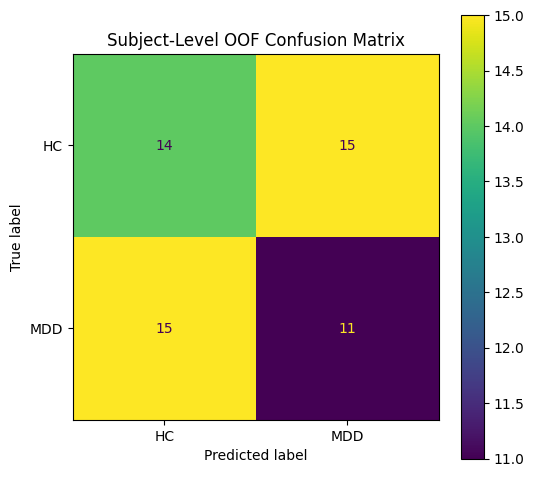

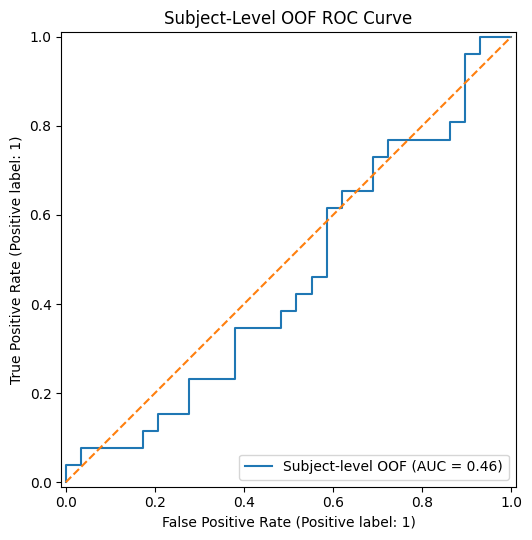

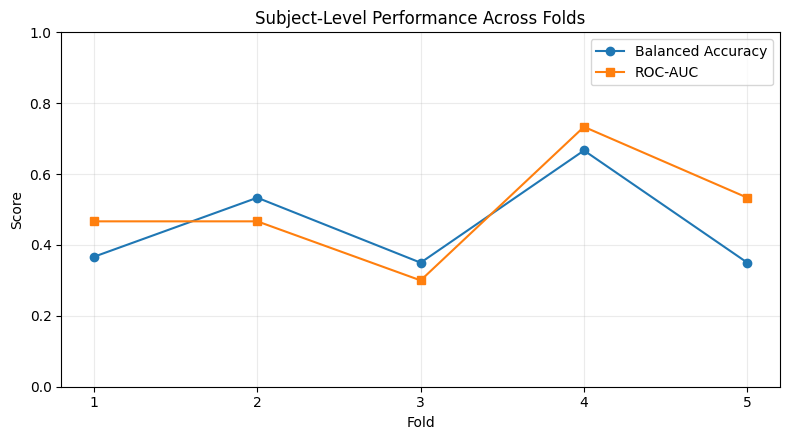

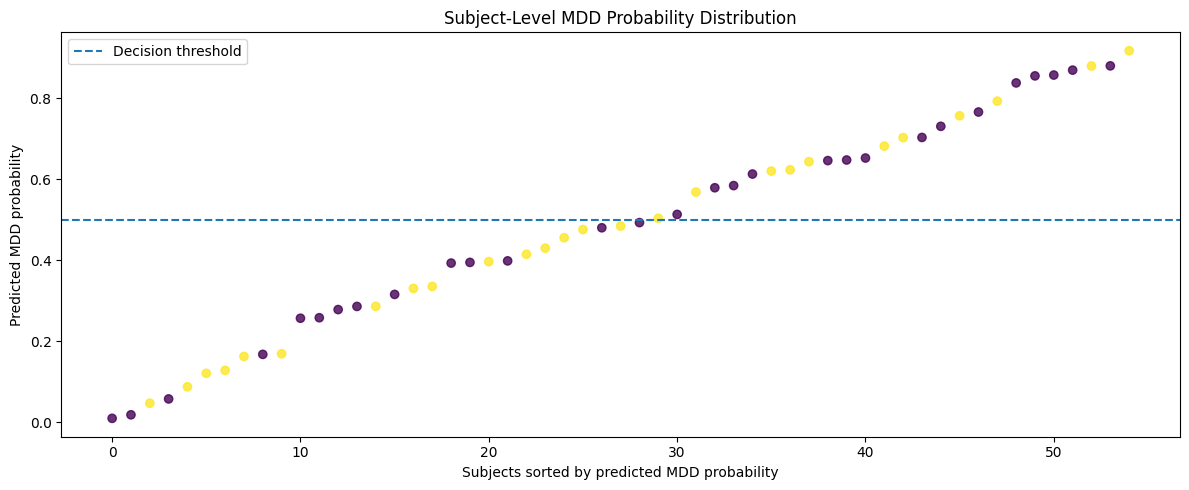

In [69]:
# Figure 6: confusion matrix
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(
    subject_oof["label"],
    subject_oof["prediction"],
    display_labels=["HC", "MDD"],
    values_format="d",
    ax=ax
)
ax.set_title("Subject-Level OOF Confusion Matrix")
plt.tight_layout()
plt.show()

# Figure 7: ROC curve
fig, ax = plt.subplots(figsize=(6.5, 5.5))
RocCurveDisplay.from_predictions(
    subject_oof["label"],
    subject_oof["prob_mdd"],
    name="Subject-level OOF",
    ax=ax
)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("Subject-Level OOF ROC Curve")
plt.tight_layout()
plt.show()

# Figure 8: fold performance
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(1, N_SPLITS + 1)
ax.plot(x, fold_df["Balanced Accuracy"], marker="o", label="Balanced Accuracy")
ax.plot(x, fold_df["ROC-AUC"], marker="s", label="ROC-AUC")
ax.set_xticks(x)
ax.set_ylim(0, 1)
ax.set_xlabel("Fold")
ax.set_ylabel("Score")
ax.set_title("Subject-Level Performance Across Folds")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Figure 9: subject probabilities
plot_subjects = subject_oof.sort_values("prob_mdd").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(plot_subjects))
ax.scatter(x, plot_subjects["prob_mdd"], c=plot_subjects["label"], alpha=0.8)
ax.axhline(0.5, linestyle="--", label="Decision threshold")
ax.set_xlabel("Subjects sorted by predicted MDD probability")
ax.set_ylabel("Predicted MDD probability")
ax.set_title("Subject-Level MDD Probability Distribution")
ax.legend()
plt.tight_layout()
plt.show()

## 13. Train an Interpretation Model on All Extracted Features

This model is fitted **after** cross-validated evaluation and is used only to summarize feature importance. It must not replace the OOF performance estimate.

,Feature,Importance
0,Fp2_IMF3_SampEn,242
1,Fp2_IMF1_SampEn,214
2,Fp2_IMF3_PSD,207
3,Fp2_IMF2_PSD,182
4,Fpz_IMF2_PSD,181
5,Fpz_IMF3_PSD,169
6,Fp1_IMF1_RMS,165
7,Fpz_IMF1_SampEn,154
8,Fp2_IMF2_SampEn,152
9,Fp1_IMF3_SampEn,146


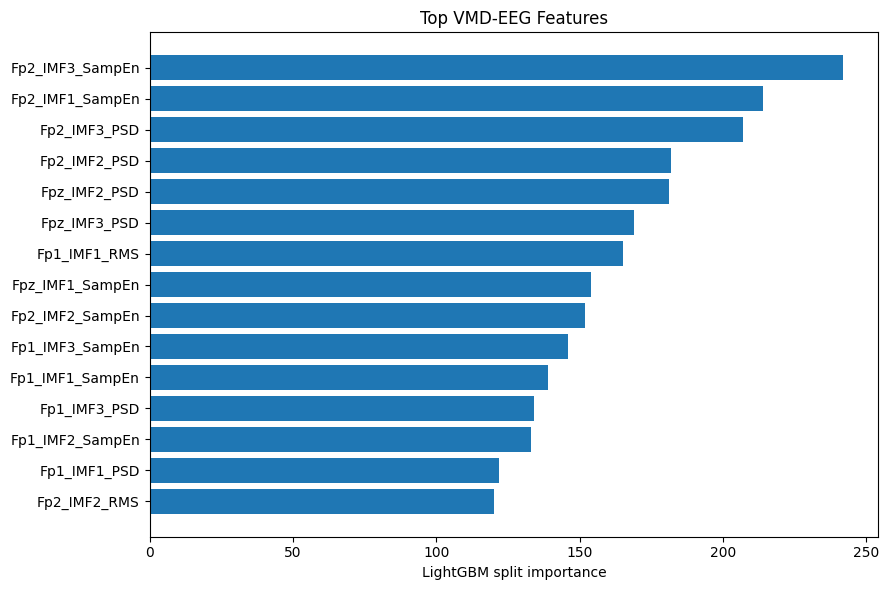

13915

In [70]:
medians_all = feature_df[FEATURE_COLS].median()
X_all = feature_df[FEATURE_COLS].fillna(medians_all).to_numpy(dtype=np.float32)
y_all = feature_df["label"].to_numpy(dtype=np.int8)

nwin_all = feature_df.groupby("subject_id")["window_idx"].transform("count").to_numpy()
weights_all = (1.0 / nwin_all).astype(np.float32)
weights_all *= len(weights_all) / weights_all.sum()

interpret_model = LGBMClassifier(**MODEL_PARAMS)
interpret_model.fit(X_all, y_all, sample_weight=weights_all)

importance_df = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Importance": interpret_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

display(importance_df.head(15))

# Figure 10: top feature importance
top = importance_df.head(15).sort_values("Importance")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["Feature"], top["Importance"])
ax.set_xlabel("LightGBM split importance")
ax.set_title("Top VMD-EEG Features")
plt.tight_layout()
plt.show()

del X_all, y_all, weights_all, interpret_model
gc.collect()

## 14. Save Results

In [72]:
OUTPUT_DIR = Path("/kaggle/working/modma_ultra_memory_safe_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

feature_df.to_csv(OUTPUT_DIR / "window_features.csv", index=False)
fold_df.to_csv(OUTPUT_DIR / "fold_metrics.csv", index=False)
subject_oof.to_csv(OUTPUT_DIR / "subject_oof_predictions.csv", index=False)
window_oof.to_csv(OUTPUT_DIR / "window_oof_predictions.csv", index=False)
importance_df.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)

pd.DataFrame([final_subject_metrics]).to_csv(
    OUTPUT_DIR / "final_subject_metrics.csv",
    index=False
)

print("Saved:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print(" -", p.name)

Saved:
 - feature_importance.csv
 - final_subject_metrics.csv
 - fold_metrics.csv
 - subject_oof_predictions.csv
 - window_features.csv
 - window_oof_predictions.csv


# 15. Interpretation and Stability Notes

### Primary result
Use **subject-level out-of-fold (OOF)** performance as the primary result. Window-level observations from one participant are correlated and are not independent patients.

### Why two Tesla T4 GPUs did not prevent the crash
The expensive VMD + entropy extraction is primarily a **CPU/system-RAM** workload. Kaggle GPU VRAM and system RAM are separate resources. Two T4 GPUs therefore do not solve a native-memory accumulation problem inside a long-lived Python kernel.

### Why this version is safer
The expensive work for each subject occurs in a fresh child process. When that process exits, Linux releases all of its memory. This is stronger than `del` + `gc.collect()` alone.

### Safe sensitivity analysis
Run the complete notebook first with:

```python
MAX_WINDOWS_PER_SUBJECT = 12   # 48 s
```

If stable, create a new cache directory and test:

```python
MAX_WINDOWS_PER_SUBJECT = 18   # 72 s
```

then:

```python
MAX_WINDOWS_PER_SUBJECT = 24   # 96 s
```

Do not select the final window count only because it produces the highest test score; report the sensitivity analysis transparently.

In [79]:
# ============================================================
# FIND ALL DATAFRAMES CURRENTLY IN MEMORY
# ============================================================

import pandas as pd

print("DataFrames currently available:\n")

found = False

for name, obj in globals().items():

    if isinstance(obj, pd.DataFrame):

        found = True

        print(
            f"{name:<30} shape = {obj.shape}"
        )

if not found:
    print("No pandas DataFrames are currently defined.")

DataFrames currently available:

metadata                       shape = (55, 13)
data_df                        shape = (55, 13)
feature_df                     shape = (660, 31)
subject_table                  shape = (55, 3)
fold_df                        shape = (5, 8)
subject_oof                    shape = (55, 6)
window_oof                     shape = (660, 7)
summary                        shape = (7, 2)
plot_subjects                  shape = (55, 6)
importance_df                  shape = (27, 2)
top                            shape = (15, 2)


In [81]:
print("feature_df shape:", feature_df.shape)

print("\nColumns:")
print(feature_df.columns.tolist())

print("\nFirst 5 rows:")
display(feature_df.head())

feature_df shape: (660, 31)

Columns:
['Fp1_IMF1_SampEn', 'Fp1_IMF1_RMS', 'Fp1_IMF1_PSD', 'Fp1_IMF2_SampEn', 'Fp1_IMF2_RMS', 'Fp1_IMF2_PSD', 'Fp1_IMF3_SampEn', 'Fp1_IMF3_RMS', 'Fp1_IMF3_PSD', 'Fpz_IMF1_SampEn', 'Fpz_IMF1_RMS', 'Fpz_IMF1_PSD', 'Fpz_IMF2_SampEn', 'Fpz_IMF2_RMS', 'Fpz_IMF2_PSD', 'Fpz_IMF3_SampEn', 'Fpz_IMF3_RMS', 'Fpz_IMF3_PSD', 'Fp2_IMF1_SampEn', 'Fp2_IMF1_RMS', 'Fp2_IMF1_PSD', 'Fp2_IMF2_SampEn', 'Fp2_IMF2_RMS', 'Fp2_IMF2_PSD', 'Fp2_IMF3_SampEn', 'Fp2_IMF3_RMS', 'Fp2_IMF3_PSD', 'subject_id', 'diagnosis', 'label', 'window_idx']

First 5 rows:


,Fp1_IMF1_SampEn,Fp1_IMF1_RMS,Fp1_IMF1_PSD,Fp1_IMF2_SampEn,Fp1_IMF2_RMS,Fp1_IMF2_PSD,Fp1_IMF3_SampEn,Fp1_IMF3_RMS,Fp1_IMF3_PSD,Fpz_IMF1_SampEn,...,Fp2_IMF2_SampEn,Fp2_IMF2_RMS,Fp2_IMF2_PSD,Fp2_IMF3_SampEn,Fp2_IMF3_RMS,Fp2_IMF3_PSD,subject_id,diagnosis,label,window_idx
0,0.588552,0.114637,0.012272,0.114255,0.411663,0.000047,0.080853,0.637449,0.000042,0.589021,...,0.115525,0.430512,0.000036,0.099016,0.605431,0.000032,2010001,MDD,1,0
1,0.574156,0.132374,0.018700,0.118707,0.409529,0.000039,0.104004,0.692829,0.000033,0.572320,...,0.119034,0.426178,0.000032,0.102504,0.662208,0.000028,2010001,MDD,1,1
2,0.456959,0.129330,0.014868,0.118040,0.325472,0.000102,0.120041,0.676572,0.000094,0.405096,...,0.133829,0.401860,0.000067,0.117062,0.573127,0.000064,2010001,MDD,1,2
3,0.510207,0.134120,0.019161,0.092089,0.368075,0.000035,0.081505,0.610364,0.000036,0.529002,...,0.085912,0.463603,0.000026,0.080029,0.520090,0.000026,2010001,MDD,1,3
4,0.590896,0.174395,0.031689,0.084565,0.437366,0.000039,0.083226,0.536115,0.000039,0.586539,...,0.082640,0.514261,0.000029,0.083844,0.465658,0.000029,2010001,MDD,1,4


In [82]:
# Temporary alias
features_df = feature_df.copy()

print("features_df created:", features_df.shape)

features_df created: (660, 31)


In [83]:
print(features_df.columns.tolist())

['Fp1_IMF1_SampEn', 'Fp1_IMF1_RMS', 'Fp1_IMF1_PSD', 'Fp1_IMF2_SampEn', 'Fp1_IMF2_RMS', 'Fp1_IMF2_PSD', 'Fp1_IMF3_SampEn', 'Fp1_IMF3_RMS', 'Fp1_IMF3_PSD', 'Fpz_IMF1_SampEn', 'Fpz_IMF1_RMS', 'Fpz_IMF1_PSD', 'Fpz_IMF2_SampEn', 'Fpz_IMF2_RMS', 'Fpz_IMF2_PSD', 'Fpz_IMF3_SampEn', 'Fpz_IMF3_RMS', 'Fpz_IMF3_PSD', 'Fp2_IMF1_SampEn', 'Fp2_IMF1_RMS', 'Fp2_IMF1_PSD', 'Fp2_IMF2_SampEn', 'Fp2_IMF2_RMS', 'Fp2_IMF2_PSD', 'Fp2_IMF3_SampEn', 'Fp2_IMF3_RMS', 'Fp2_IMF3_PSD', 'subject_id', 'diagnosis', 'label', 'window_idx']


In [84]:
# ============================================================
# CREATE TEMPORAL 50/50 TRAIN-TEST SPLIT
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Verify required columns
# ------------------------------------------------------------

required_columns = [
    "subject_id",
    "window_idx",
    "label"
]

for col in required_columns:
    if col not in feature_df.columns:
        raise KeyError(
            f"Missing required column: {col}"
        )

# ------------------------------------------------------------
# Find the maximum window index for each subject
# ------------------------------------------------------------

max_window = (
    feature_df
    .groupby("subject_id")["window_idx"]
    .transform("max")
)

# ------------------------------------------------------------
# Relative position of each window within the subject
# ------------------------------------------------------------

window_fraction = (
    feature_df["window_idx"]
    /
    max_window.replace(0, 1)
)

# ------------------------------------------------------------
# First 50% -> training
# Second 50% -> testing
# ------------------------------------------------------------

train_df = (
    feature_df[
        window_fraction < 0.50
    ]
    .copy()
)

test_df = (
    feature_df[
        window_fraction >= 0.50
    ]
    .copy()
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("train_df shape:", train_df.shape)
print("test_df shape :", test_df.shape)

print("\nTraining class distribution:")
print(
    train_df["label"]
    .value_counts()
    .sort_index()
)

print("\nTesting class distribution:")
print(
    test_df["label"]
    .value_counts()
    .sort_index()
)

print(
    "\nUnique subjects in training:",
    train_df["subject_id"].nunique()
)

print(
    "Unique subjects in testing:",
    test_df["subject_id"].nunique()
)

train_df shape: (330, 31)
test_df shape : (330, 31)

Training class distribution:
label
0    174
1    156
Name: count, dtype: int64

Testing class distribution:
label
0    174
1    156
Name: count, dtype: int64

Unique subjects in training: 55
Unique subjects in testing: 55


In [90]:
# ============================================================
# DEFINE MODEL FEATURE COLUMNS
# ============================================================

META_COLUMNS = [
    "subject_id",
    "diagnosis",
    "label",
    "window_idx"
]

ALL_FEATURES = [
    col
    for col in feature_df.columns
    if col not in META_COLUMNS
]

print("Number of model features:", len(ALL_FEATURES))

print("\nFeatures:")
for feature in ALL_FEATURES:
    print(feature)

Number of model features: 27

Features:
Fp1_IMF1_SampEn
Fp1_IMF1_RMS
Fp1_IMF1_PSD
Fp1_IMF2_SampEn
Fp1_IMF2_RMS
Fp1_IMF2_PSD
Fp1_IMF3_SampEn
Fp1_IMF3_RMS
Fp1_IMF3_PSD
Fpz_IMF1_SampEn
Fpz_IMF1_RMS
Fpz_IMF1_PSD
Fpz_IMF2_SampEn
Fpz_IMF2_RMS
Fpz_IMF2_PSD
Fpz_IMF3_SampEn
Fpz_IMF3_RMS
Fpz_IMF3_PSD
Fp2_IMF1_SampEn
Fp2_IMF1_RMS
Fp2_IMF1_PSD
Fp2_IMF2_SampEn
Fp2_IMF2_RMS
Fp2_IMF2_PSD
Fp2_IMF3_SampEn
Fp2_IMF3_RMS
Fp2_IMF3_PSD


In [91]:
# ============================================================
# DEFINE FEATURE GROUPS
# ============================================================

SAMPEN_FEATURES = [
    col for col in ALL_FEATURES
    if col.endswith("_SampEn")
]

RMS_FEATURES = [
    col for col in ALL_FEATURES
    if col.endswith("_RMS")
]

PSD_FEATURES = [
    col for col in ALL_FEATURES
    if col.endswith("_PSD")
]

FUSION_FEATURES = ALL_FEATURES.copy()

print("Sample Entropy features:", len(SAMPEN_FEATURES))
print("RMS features           :", len(RMS_FEATURES))
print("PSD features           :", len(PSD_FEATURES))
print("Fusion features        :", len(FUSION_FEATURES))

Sample Entropy features: 9
RMS features           : 9
PSD features           : 9
Fusion features        : 27


In [94]:
# ============================================================
# CHECK POSSIBLE MODEL-SELECTION VARIABLES
# ============================================================

possible_vars = [
    "BEST_PARAMS",
    "best_params",
    "best_param",
    "best_config",
    "best_model_params",
    "PARAM_GRID",
    "param_grid"
]

for name in possible_vars:
    if name in globals():
        print(f"\n{name} exists:")
        print(globals()[name])

In [95]:
print("fold_df columns:")
print(fold_df.columns.tolist())

display(fold_df.head())

fold_df columns:
['Accuracy', 'Balanced Accuracy', 'Precision', 'Sensitivity', 'Specificity', 'F1', 'ROC-AUC', 'Fold']


,Accuracy,Balanced Accuracy,Precision,Sensitivity,Specificity,F1,ROC-AUC,Fold
0,0.363636,0.366667,0.400000,0.333333,0.400000,0.363636,0.466667,1
1,0.545455,0.533333,0.500000,0.400000,0.666667,0.444444,0.466667,2
2,0.363636,0.350000,0.250000,0.200000,0.500000,0.222222,0.300000,3
3,0.636364,0.666667,0.555556,1.000000,0.333333,0.714286,0.733333,4
4,0.363636,0.350000,0.250000,0.200000,0.500000,0.222222,0.533333,5


In [96]:
# ============================================================
# FIND MODEL / PARAMETER VARIABLES
# ============================================================

keywords = [
    "param",
    "model",
    "clf",
    "classifier",
    "lgb",
    "best"
]

print("Possible model-related variables:\n")

for name in sorted(globals().keys()):

    low = name.lower()

    if any(k in low for k in keywords):

        obj = globals()[name]

        # Avoid printing huge modules / builtins
        if name.startswith("_"):
            continue

        print(
            f"{name:<35} "
            f"type = {type(obj).__name__}"
        )

Possible model-related variables:

LGBMClassifier                      type = type
LGBM_DEVICE                         type = str
MODEL_PARAMS                        type = dict
detect_lgbm_device                  type = function
lgb                                 type = module


In [99]:
# ============================================================
# CHECK SPECIFIC VARIABLES WE NEED
# ============================================================

variables_to_check = [
    "BEST_PARAMS",
    "best_params",
    "BEST_FEATURES",
    "BEST_FEATURE_SET",
    "best_model",
    "final_model",
    "model",
    "clf",
    "classifier",
    "LGBM_DEVICE",
    "LGBM_MAX_BIN"
]

for name in variables_to_check:

    if name in globals():

        print("\n" + "=" * 60)
        print(name)
        print("=" * 60)

        try:
            print(globals()[name])
        except Exception:
            print(
                "Variable exists but could not be printed."
            )


LGBM_DEVICE
gpu


In [101]:
# ============================================================
# FIND TRAINED LIGHTGBM OBJECTS
# ============================================================

from lightgbm import LGBMClassifier

print("LightGBM classifiers currently in memory:\n")

found = False

for name, obj in globals().items():

    if isinstance(obj, LGBMClassifier):

        found = True

        print("Variable:", name)

        try:
            print(
                "Fitted:",
                hasattr(obj, "booster_")
            )
        except Exception:
            pass

        try:
            print(
                "Parameters:",
                obj.get_params()
            )
        except Exception:
            pass

        print("-" * 70)

if not found:
    print(
        "No LGBMClassifier object found in memory."
    )

LightGBM classifiers currently in memory:

No LGBMClassifier object found in memory.


In [104]:
# ============================================================
# SEARCH CURRENT VARIABLES FOR MODEL SETTINGS
# ============================================================

keywords = [
    "estim",
    "leaf",
    "depth",
    "learning",
    "boost",
    "param",
    "threshold"
]

print("Possible model-configuration variables:\n")

for name in sorted(globals().keys()):

    if name.startswith("_"):
        continue

    lower_name = name.lower()

    if any(k in lower_name for k in keywords):

        obj = globals()[name]

        # Don't print modules/functions
        if callable(obj):
            continue

        print(
            f"{name:<35} = {obj}"
        )

Possible model-configuration variables:

MODEL_PARAMS                        = {'objective': 'binary', 'n_estimators': 250, 'learning_rate': 0.03, 'num_leaves': 15, 'min_child_samples': 20, 'subsample': 0.85, 'colsample_bytree': 0.85, 'reg_alpha': 0.1, 'reg_lambda': 0.2, 'random_state': 42, 'n_jobs': 2, 'verbosity': -1, 'device_type': 'gpu', 'max_bin': 63}
possible_params                     = ['BEST_PARAMS', 'best_params', 'params', 'model_params', 'lgb_params', 'LGBM_PARAMS', 'best_config', 'config']


In [105]:
BEST_PARAMS = MODEL_PARAMS.copy()

In [106]:
# ============================================================
# STEP 1 — SET BEST_PARAMS FROM EXISTING NOTEBOOK PARAMETERS
# ============================================================

BEST_PARAMS = MODEL_PARAMS.copy()

print("BEST_PARAMS:")
print(BEST_PARAMS)

BEST_PARAMS:
{'objective': 'binary', 'n_estimators': 250, 'learning_rate': 0.03, 'num_leaves': 15, 'min_child_samples': 20, 'subsample': 0.85, 'colsample_bytree': 0.85, 'reg_alpha': 0.1, 'reg_lambda': 0.2, 'random_state': 42, 'n_jobs': 2, 'verbosity': -1, 'device_type': 'gpu', 'max_bin': 63}


In [107]:
# ============================================================
# STEP 2 — SET BEST FEATURES
# ============================================================

BEST_FEATURE_SET = "VMD_Fusion"
BEST_FEATURES = ALL_FEATURES.copy()

print("Feature set:", BEST_FEATURE_SET)
print("Number of features:", len(BEST_FEATURES))

Feature set: VMD_Fusion
Number of features: 27


In [108]:
# ============================================================
# STEP 3 — PREPARE X_train, y_train, X_test, y_test
# ============================================================

import numpy as np

train_features = (
    train_df[BEST_FEATURES]
    .replace([np.inf, -np.inf], np.nan)
    .copy()
)

test_features = (
    test_df[BEST_FEATURES]
    .replace([np.inf, -np.inf], np.nan)
    .copy()
)

# Training-set medians only
train_medians = train_features.median()

X_train = (
    train_features
    .fillna(train_medians)
    .astype(np.float32)
)

X_test = (
    test_features
    .fillna(train_medians)
    .astype(np.float32)
)

y_train = (
    train_df["label"]
    .astype(int)
    .to_numpy()
)

y_test = (
    test_df["label"]
    .astype(int)
    .to_numpy()
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print(
    "Missing X_train:",
    X_train.isna().sum().sum()
)

print(
    "Missing X_test:",
    X_test.isna().sum().sum()
)

X_train: (330, 27)
y_train: (330,)
X_test : (330, 27)
y_test : (330,)
Missing X_train: 0
Missing X_test: 0


In [109]:
# ============================================================
# STEP 4 — CREATE FINAL LIGHTGBM MODEL
# ============================================================

from lightgbm import LGBMClassifier

final_model = LGBMClassifier(
    **BEST_PARAMS
)

print(final_model)

LGBMClassifier(colsample_bytree=0.85, device_type='gpu', learning_rate=0.03,
               max_bin=63, n_estimators=250, n_jobs=2, num_leaves=15,
               objective='binary', random_state=42, reg_alpha=0.1,
               reg_lambda=0.2, subsample=0.85, verbosity=-1)


In [110]:
# ============================================================
# STEP 5 — TRAIN FINAL MODEL
# ============================================================

final_model.fit(
    X_train,
    y_train
)

print("Final LightGBM model trained successfully.")

Final LightGBM model trained successfully.


In [111]:
# ============================================================
# STEP 6 — VERIFY TRAINED MODEL
# ============================================================

print(
    "final_model exists:",
    "final_model" in globals()
)

print(
    "Fitted:",
    hasattr(final_model, "booster_")
)

print(
    "Number of model features:",
    final_model.n_features_in_
)

final_model exists: True
Fitted: True
Number of model features: 27


In [112]:
# ============================================================
# STEP 7 — EXPORT FOR STREAMLIT
# ============================================================

import joblib
import json
from pathlib import Path

EXPORT_DIR = Path(
    "/kaggle/working/streamlit_export"
)

EXPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Save model
joblib.dump(
    final_model,
    EXPORT_DIR / "lightgbm_model.pkl"
)

# Save medians
joblib.dump(
    train_medians,
    EXPORT_DIR / "feature_medians.pkl"
)

# Save config
config = {
    "model_name": "MODMA_VMD_LightGBM",

    "feature_set": BEST_FEATURE_SET,

    "features": list(BEST_FEATURES),

    "label_mapping": {
        "HC": 0,
        "MDD": 1
    },

    "sampling_frequency": 250,

    "channels": [
        "Fp1",
        "Fpz",
        "Fp2"
    ],

    "selected_imfs": 3
}

with open(
    EXPORT_DIR / "model_config.json",
    "w"
) as f:
    json.dump(
        config,
        f,
        indent=4
    )

print("Export completed.")

for p in EXPORT_DIR.iterdir():
    print(p.name)

Export completed.
model_config.json
lightgbm_model.pkl
feature_medians.pkl


In [115]:
import shutil

shutil.make_archive(
    "/kaggle/working/MODMA_Streamlit_Deployment",
    "zip",
    "/kaggle/working/streamlit_export"
)

print("/kaggle/working/MODMA_Streamlit_Deployment.zip")

/kaggle/working/MODMA_Streamlit_Deployment.zip
